# Parameter Distributions

Sampling strategies for CBC signal injection parameters: mass priors, chirp-time parameterisation, template placement metrics, and the SNR prior.

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import math
import time
import multiprocessing
from math import atan2, degrees

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import beta, halfnorm
from tqdm import tqdm

import lal
from pycbc import distributions
from pycbc.conversions import (
    tau0_from_mass1_mass2, tau3_from_mass1_mass2,
    mass1_from_tau0_tau3, mass2_from_tau0_tau3,
    mchirp_from_tau0, mchirp_from_mass1_mass2,
    mass1_from_mchirp_q, mass2_from_mchirp_q,
    mass2_from_mchirp_mass1, _mass2_from_mchirp_mass1,
)

In [2]:
m_min, m_max, fL = 7.0, 50.0, 20.0
num_samples = 10_000_000

## 1. Uniform Mass Distributions

Sample m1, m2 independently and uniformly in [m_min, m_max] with m1 >= m2. This induces non-uniform distributions on derived quantities (Mchirp, q, M).

In [3]:
foo_1 = np.random.uniform(m_min, m_max, num_samples)
foo_2 = np.random.uniform(m_min, m_max, num_samples)
masses = np.column_stack((foo_1, foo_2))
masses = np.sort(masses, axis=1)
mass1, mass2 = masses[:, 1], masses[:, 0]

mchirp = (mass1 * mass2) ** (3. / 5.) / (mass1 + mass2) ** (1. / 5.)
q = mass1 / mass2
M = mass1 + mass2

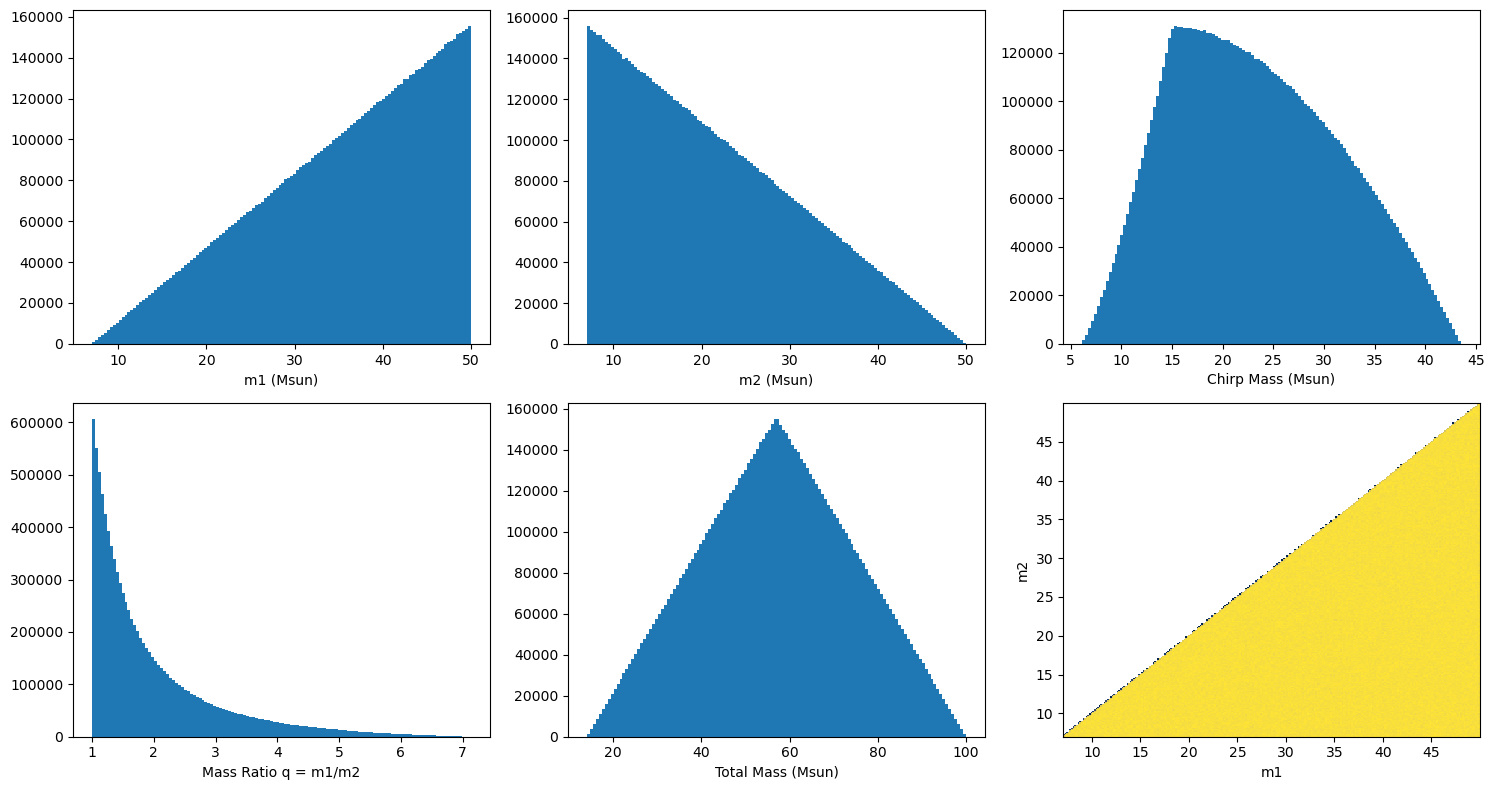

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].hist(mass1, bins=128); axes[0, 0].set_xlabel('m1 (Msun)')
axes[0, 1].hist(mass2, bins=128); axes[0, 1].set_xlabel('m2 (Msun)')
axes[0, 2].hist(mchirp, bins=128); axes[0, 2].set_xlabel('Chirp Mass (Msun)')
axes[1, 0].hist(q, bins=128); axes[1, 0].set_xlabel('Mass Ratio q = m1/m2')
axes[1, 1].hist(M, bins=128); axes[1, 1].set_xlabel('Total Mass (Msun)')
axes[1, 2].hist2d(mass1, mass2, bins=256, norm=mpl.colors.LogNorm(), cmap='cividis')
axes[1, 2].set_xlabel('m1'); axes[1, 2].set_ylabel('m2')
plt.tight_layout()
plt.show()

## 2. Chirp Time (τ) Priors

BoundedPriors samples on lines of constant chirp time τ. A beta distribution on τ provides importance sampling so that longer-duration (lighter) signals receive proportionally more samples, matching the arc length of each iso-τ curve in the (m1, m2) plane.

In [5]:
def get_mchirp_priors(ml, mu):
    min_mchirp = (ml * ml / (ml + ml) ** 2.) ** (3. / 5) * (ml + ml)
    max_mchirp = (mu * mu / (mu + mu) ** 2.) ** (3. / 5) * (mu + mu)
    return min_mchirp, max_mchirp

def get_tau_priors(ml, mu, lf):
    min_mchirp, max_mchirp = get_mchirp_priors(ml, mu)
    G, c = 6.67e-11, 3.0e8
    tau = lambda mc: 5. * (8. * np.pi * lf) ** (-8. / 3.) * (mc * 1.989e30 * G / c ** 3.) ** (-5. / 3.)
    return tau(max_mchirp), tau(min_mchirp)

In [6]:
class BoundedPriors:

    def __init__(self, mu, ml, lf):
        self.lf = lf
        self.mu = mu
        self.ml = ml
        G = 6.67e-11
        c = 3.0e8
        self.const = (5. * (8. * np.pi * lf) ** (-8. / 3.)) * (1.989e30 * G / c ** 3.) ** (-5. / 3.)

    def _intersection_with_m1_eq_m2(self, tau):
        C_1dash = self.const * 2 ** (1. / 3.)
        return (tau / C_1dash) ** (-3. / 5.)

    def _intersection_with_m2_when_m1_is_mu(self, tau):
        C_2dash = self.const / self.mu
        C_3dash = (tau / C_2dash) ** 3.
        m2_when_m1_is_mu = np.array([np.roots([c3d, 0.0, -1, -self.mu]) for c3d in C_3dash])
        m2_when_m1_is_mu = np.array([np.real(foo[np.isreal(foo)])[0] for foo in m2_when_m1_is_mu])
        return m2_when_m1_is_mu

    def _intersection_with_m1_when_m2_is_ml(self, tau):
        C_4dash = self.const / self.ml
        C_5dash = (tau / C_4dash) ** 3.
        m1_when_m2_is_ml = np.array([np.roots([c5d, 0.0, -1, -self.ml]) for c5d in C_5dash])
        m1_when_m2_is_ml = np.array([np.real(foo[np.isreal(foo)])[0] for foo in m1_when_m2_is_ml])
        return m1_when_m2_is_ml

    def _get_m1_upper_bounds(self, m2_when_m1_is_mu, m1_when_m2_is_ml):
        upper_bounds = m2_when_m1_is_mu.copy()
        idxs = m2_when_m1_is_mu < self.ml
        alt_idxs = m2_when_m1_is_mu >= self.ml
        upper_bounds[idxs] = m1_when_m2_is_ml[idxs]
        upper_bounds[alt_idxs] = np.full(sum(alt_idxs), self.mu)
        return upper_bounds

    def _get_m2_from_m1_tau(self, mass1, tau):
        C_6dash = (tau / (self.const / mass1)) ** 3.
        mass2_roots = np.array([np.roots([c6d, 0.0, -1, -_m1]) for c6d, _m1 in zip(C_6dash, mass1)])
        mass2 = np.array([np.real(foo[np.isreal(foo)])[0] for foo in mass2_roots])
        return mass2

    def _common_umc_utau(self, tau):
        intersc_diagonal = self._intersection_with_m1_eq_m2(tau)
        m2_when_m1_is_mu = self._intersection_with_m2_when_m1_is_mu(tau)
        m1_when_m2_is_ml = self._intersection_with_m1_when_m2_is_ml(tau)
        upper_bounds = self._get_m1_upper_bounds(m2_when_m1_is_mu, m1_when_m2_is_ml)
        lower_bounds = intersc_diagonal
        mass1 = np.array([np.random.uniform(lb, ub) for lb, ub in zip(lower_bounds, upper_bounds)])
        mass2 = self._get_m2_from_m1_tau(mass1, tau)
        q = mass1 / mass2
        mchirp = (mass1 * mass2 / (mass1 + mass2) ** 2.) ** (3. / 5) * (mass1 + mass2)
        return (mass1, mass2, q, mchirp)

    def get_arc_length_given_tau(self, tau, num_pts):
        intersc_diagonal = self._intersection_with_m1_eq_m2(tau)
        m2_when_m1_is_mu = self._intersection_with_m2_when_m1_is_mu(tau)
        m1_when_m2_is_ml = self._intersection_with_m1_when_m2_is_ml(tau)
        upper_bounds = self._get_m1_upper_bounds(m2_when_m1_is_mu, m1_when_m2_is_ml)[0]
        lower_bounds = intersc_diagonal[0]
        mass1 = np.linspace(lower_bounds, upper_bounds, num_pts)
        mass1.sort()
        mass2 = self._get_m2_from_m1_tau(mass1, tau)
        coords = np.column_stack((mass1, mass2))
        euc_dist = lambda c1, c2: np.sqrt((c2[0] - c1[0]) ** 2 + (c2[1] - c1[1]) ** 2)
        chunk_lengths = [euc_dist(coords[i], coords[i + 1]) for i in range(len(coords) - 1)]
        return np.sum(chunk_lengths)

    def get_bounded_gwparams_from_importance_tau(self, num_samples=10_000):
        tau_lower, tau_upper = get_tau_priors(ml=self.ml, mu=self.mu, lf=self.lf)
        tau = beta.rvs(1.7, 5.25, size=num_samples) * (tau_upper - tau_lower) + tau_lower
        mass1, mass2, q, mchirp = self._common_umc_utau(tau)
        return (mass1, mass2, q, mchirp, tau)

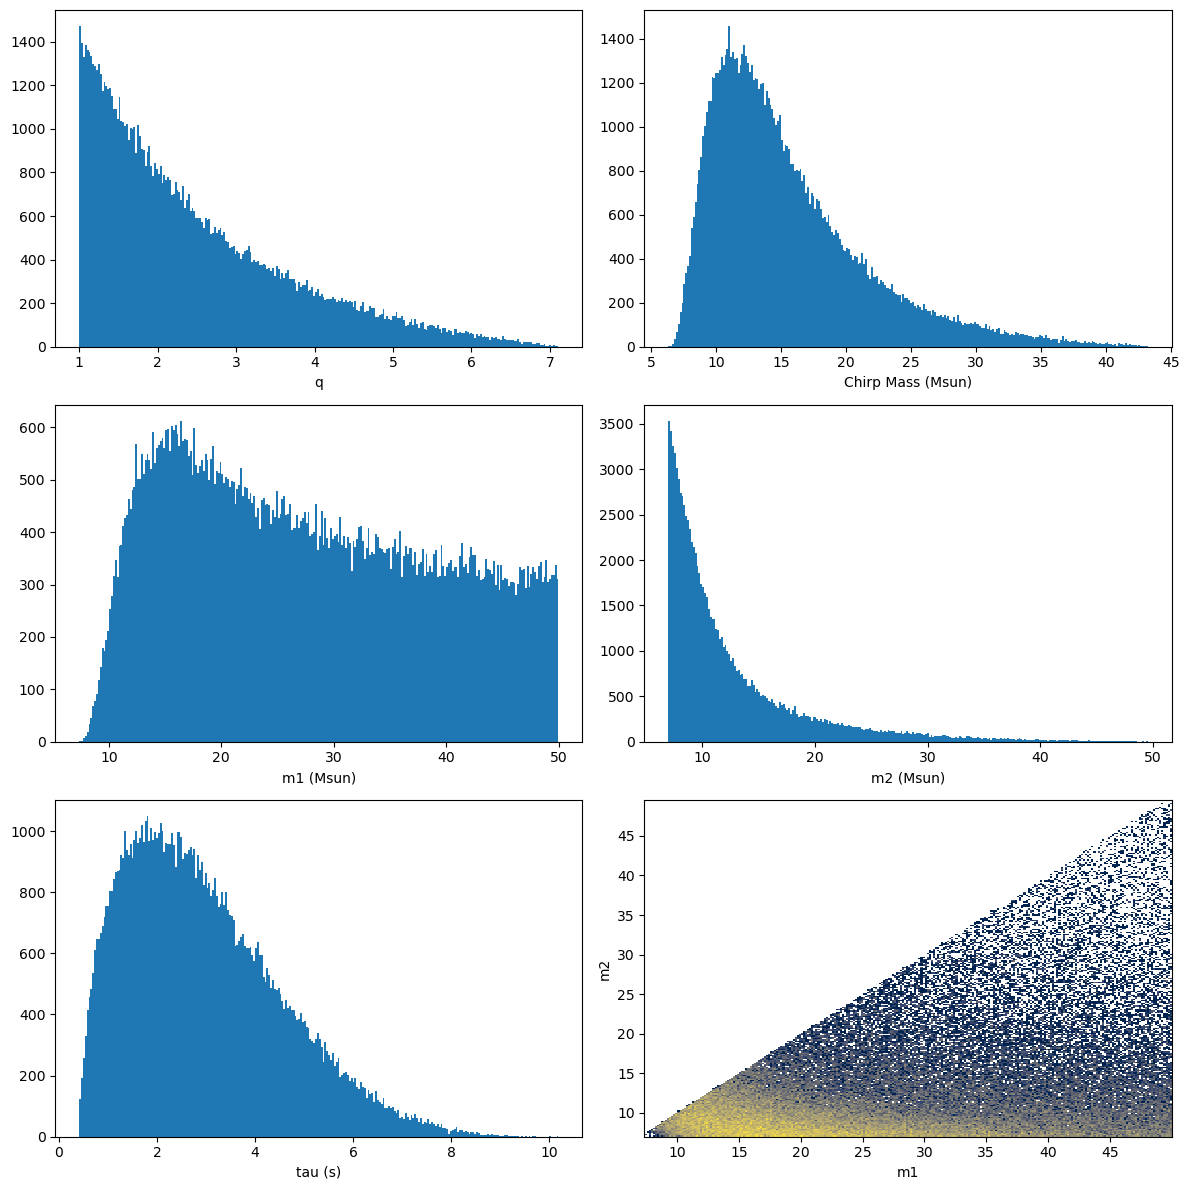

In [7]:
bp = BoundedPriors(mu=50.0, ml=7.0, lf=20.0)
mass1_b, mass2_b, q_b, mchirp_b, tau_b = bp.get_bounded_gwparams_from_importance_tau(num_samples=100_000)

bins = 256
fig, ax = plt.subplots(3, 2, figsize=(12, 12))
ax[0][0].hist(q_b, bins=bins); ax[0][0].set_xlabel('q')
ax[0][1].hist(mchirp_b, bins=bins); ax[0][1].set_xlabel('Chirp Mass (Msun)')
ax[1][0].hist(mass1_b, bins=bins); ax[1][0].set_xlabel('m1 (Msun)')
ax[1][1].hist(mass2_b, bins=bins); ax[1][1].set_xlabel('m2 (Msun)')
ax[2][0].hist(tau_b, bins=bins); ax[2][0].set_xlabel('tau (s)')
ax[2][1].hist2d(mass1_b, mass2_b, bins=256, norm=mpl.colors.LogNorm(), cmap='cividis')
ax[2][1].set_xlabel('m1'); ax[2][1].set_ylabel('m2')
plt.tight_layout()
plt.show()

### Arc Length Analysis

Arc length of each iso-τ curve in (m1, m2) space is proportional to the amount of information that chirp time represents at that duration. Shorter signals (high τ) map to longer curves because many (m1, m2) pairs share that chirp time.

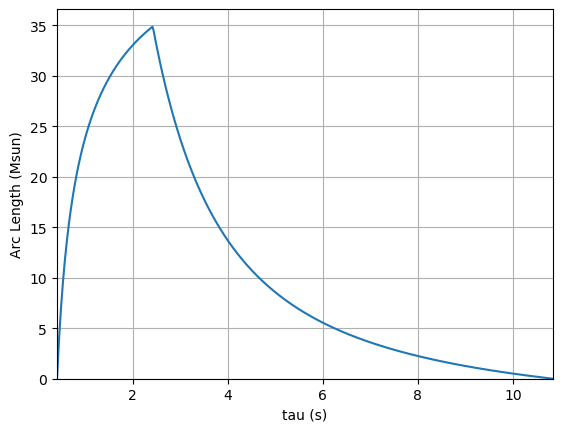

In [8]:
alt = lambda foo: np.array([foo])
tau_min, tau_max = get_tau_priors(m_min, m_max, fL)

arclens = []
taus = np.linspace(tau_min, tau_max, 500)
for _tau in taus:
    arclens.append(bp.get_arc_length_given_tau(alt(_tau), num_pts=5))

plt.figure()
plt.plot(taus, arclens)
plt.xlabel('tau (s)')
plt.ylabel('Arc Length (Msun)')
plt.xlim(tau_min, tau_max)
plt.ylim(0.0)
plt.grid()
plt.show()

### Isochronal Contours on (m1, m2)

Overlay constant-τ lines on the sampled (m1, m2) distribution.

In [9]:
def labelLine(line, x, label=None, align=True, **kwargs):
    ax = line.axes
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    if (x < xdata[0]) or (x > xdata[-1]):
        print('x label location is outside data range!')
        return
    ip = 1
    for i in range(len(xdata)):
        if x < xdata[i]:
            ip = i
            break
    y = ydata[ip-1] + (ydata[ip] - ydata[ip-1]) * (x - xdata[ip-1]) / (xdata[ip] - xdata[ip-1])
    if not label:
        label = line.get_label()
    if align:
        dx = xdata[ip] - xdata[ip-1]
        dy = ydata[ip] - ydata[ip-1]
        ang = degrees(atan2(dy, dx))
        pt = np.array([x, y]).reshape((1, 2))
        trans_angle = ax.transData.transform_angles(np.array((ang,)), pt)[0]
    else:
        trans_angle = 0
    if 'color' not in kwargs:
        kwargs['color'] = line.get_color()
    if ('horizontalalignment' not in kwargs) and ('ha' not in kwargs):
        kwargs['ha'] = 'center'
    if ('verticalalignment' not in kwargs) and ('va' not in kwargs):
        kwargs['va'] = 'center'
    if 'backgroundcolor' not in kwargs:
        kwargs['backgroundcolor'] = ax.get_facecolor()
    if 'clip_on' not in kwargs:
        kwargs['clip_on'] = True
    if 'zorder' not in kwargs:
        kwargs['zorder'] = 2.5
    ax.text(x, y, label, rotation=trans_angle, **kwargs)

def labelLines(lines, align=True, xvals=None, **kwargs):
    ax = lines[0].axes
    labLines = [line for line in lines if '_line' not in line.get_label()]
    labels = [line.get_label() for line in labLines]
    if xvals is None:
        xmin, xmax = ax.get_xlim()
        xvals = np.linspace(xmin, xmax, len(labLines) + 2)[1:-1]
    for line, x, label in zip(labLines, xvals, labels):
        labelLine(line, x, label, align, **kwargs)

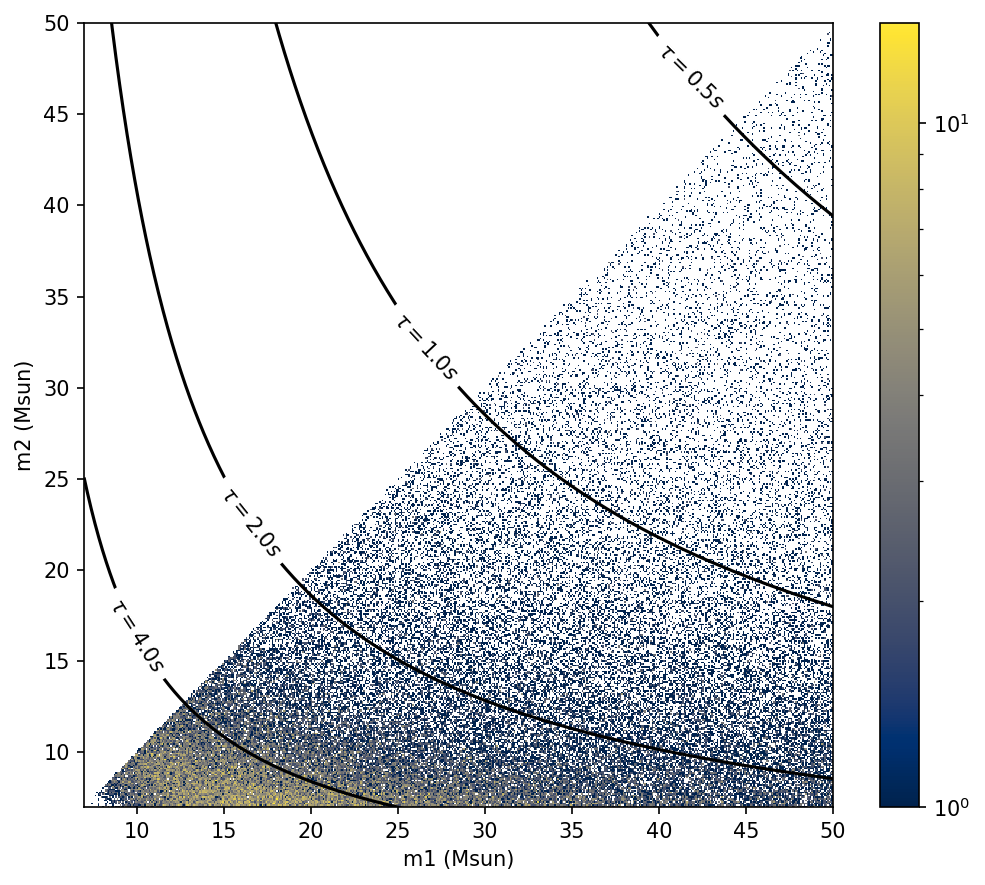

In [10]:
G, c = 6.67e-11, 3.0e8
mchirp_from_tau = lambda tau: (((5. * (8. * np.pi * fL) ** (-8. / 3.)) / tau) ** (3. / 5.)) / (1.989e30 * G / c ** 3.)

plt.figure(figsize=(7.0, 6.0), dpi=150)
plt.hist2d(mass1_b, mass2_b, cmap='cividis', bins=512, norm=mpl.colors.LogNorm())

for _tau in [0.5, 1.0, 2.0, 4.0]:
    _mc = mchirp_from_tau(_tau)
    m1_line = np.linspace(m_min, m_max, 1000)
    m2_line = [_mass2_from_mchirp_mass1(mchirp=_mc, mass1=m1i) for m1i in m1_line]
    plt.plot(m1_line, m2_line, c='k', label=r'$\tau={}s$'.format(_tau))

labelLines(plt.gca().get_lines(), xvals=(41.8, 26.6, 16.55, 10), zorder=2.5, fontsize=10)
plt.xlim(m_min, m_max)
plt.ylim(m_min, m_max)
plt.xlabel('m1 (Msun)')
plt.ylabel('m2 (Msun)')
plt.colorbar()
plt.tight_layout()
plt.show()

## 3. Template Placement: (τ₀, τ₃) Space

The chirp-time metric parameterises (m1, m2) via (τ₀, τ₃). Sampling uniformly in (τ₀, τ₃) within the physical boundary gives a different density on (m1, m2) compared to sampling uniformly on mass.

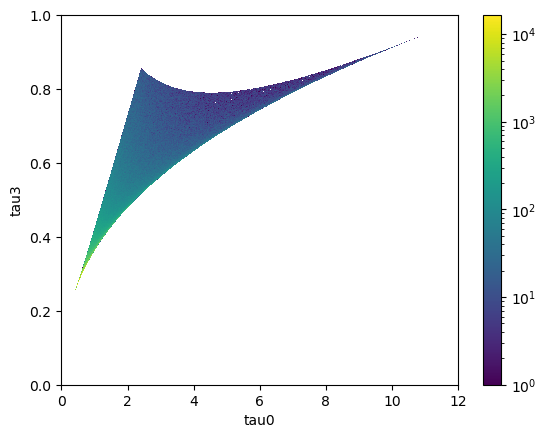

In [11]:
# Compute (tau0, tau3) for the uniform mass sample
tau0 = tau0_from_mass1_mass2(mass1, mass2, f_lower=fL)
tau3 = tau3_from_mass1_mass2(mass1, mass2, f_lower=fL)

plt.hist2d(tau0, tau3, bins=1024, norm=mpl.colors.LogNorm())
plt.xlabel('tau0')
plt.ylabel('tau3')
plt.xlim(0.0, 12.0)
plt.ylim(0.0, 1.0)
plt.colorbar()
plt.show()

In [12]:
# Boundaries of the (tau0, tau3) region
tau3_boundary_1 = tau3_from_mass1_mass2(m_max, m_max, f_lower=fL)
tau3_boundary_2 = tau3_from_mass1_mass2(m_min, m_min, f_lower=fL)
tau0_boundary_1 = tau0_from_mass1_mass2(m_max, m_max, f_lower=fL)
tau0_boundary_2 = tau0_from_mass1_mass2(m_min, m_min, f_lower=fL)
print(tau0_boundary_1, tau0_boundary_2)
print(tau3_boundary_1, tau3_boundary_2)

0.40759405349866723 10.798110809905172
0.2536220914789963 0.9406651529313066


In [13]:
def tau3_lower_boundary_from_tau0(_tau0):
    A3 = np.pi / (8.0 * (np.pi * fL) ** (5. / 3.))
    A0 = 5.0 / (256.0 * (np.pi * fL) ** (8. / 3.))
    return 4.0 * A3 * (_tau0 / (4.0 * A0)) ** (2. / 5.)

def tau3_upper_boundary_from_tau0(_tau0):
    inflection_tau0 = tau0_from_mass1_mass2(m_max, m_min, f_lower=fL)
    if _tau0 > inflection_tau0:
        mc = mchirp_from_tau0(_tau0, f_lower=fL)
        estimated_m1 = mass2_from_mchirp_mass1(mc, m_min)
        return tau3_from_mass1_mass2(estimated_m1, m_min, f_lower=fL)
    elif _tau0 < inflection_tau0:
        mc = mchirp_from_tau0(_tau0, f_lower=fL)
        estimated_m2 = mass2_from_mchirp_mass1(mc, m_max)
        return tau3_from_mass1_mass2(m_max, estimated_m2, f_lower=fL)
    else:
        return tau3_from_mass1_mass2(m_max, m_min, f_lower=fL)

100%|██████████| 10000000/10000000 [10:31<00:00, 15825.61it/s]


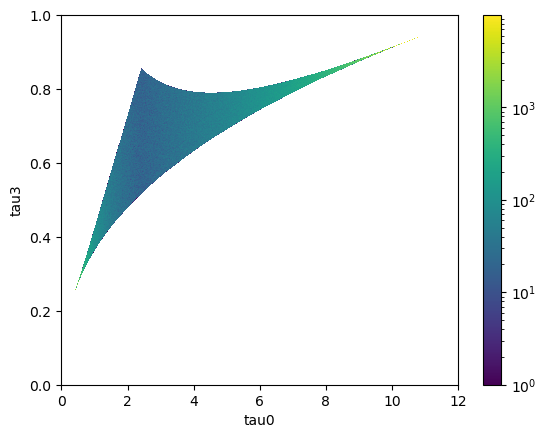

In [14]:
# Sample uniform tau0, get bounded tau3 (serial)
utau0 = np.random.uniform(tau0_boundary_1, tau0_boundary_2, num_samples)
utau3 = []
for _utau0 in tqdm(utau0):
    lb = tau3_lower_boundary_from_tau0(_utau0)
    ub = tau3_upper_boundary_from_tau0(_utau0)
    utau3.append(np.random.uniform(lb, ub))
utau3 = np.array(utau3)

plt.hist2d(utau0, utau3, bins=1024, norm=mpl.colors.LogNorm())
plt.xlabel('tau0'); plt.ylabel('tau3')
plt.xlim(0.0, 12.0); plt.ylim(0.0, 1.0)
plt.colorbar()
plt.show()

In [15]:
# Rejection sampling for strict uniform (tau0, tau3) within physical boundary
def get_good_samples(coords):
    t0, t3 = coords
    lb = tau3_lower_boundary_from_tau0(t0)
    ub = tau3_upper_boundary_from_tau0(t0)
    if lb <= t3 <= ub:
        return coords
    return (-1, -1)

n_rej = 100_000_000
rej_tau0 = np.random.uniform(tau0_boundary_1, tau0_boundary_2, n_rej)
rej_tau3 = np.random.uniform(tau3_boundary_1, tau3_boundary_2, n_rej)

pool = multiprocessing.Pool(16)
atau0, atau3 = zip(*pool.map(get_good_samples, zip(rej_tau0, rej_tau3)))
pool.close()

atau0 = np.array(atau0); atau3 = np.array(atau3)
atau0 = atau0[atau0 > 0.0]; atau3 = atau3[atau3 > 0.0]
print('Accepted: {} ({:.1f}%)'.format(len(atau0), 100 * len(atau0) / n_rej))

Accepted: 13384031 (13.4%)


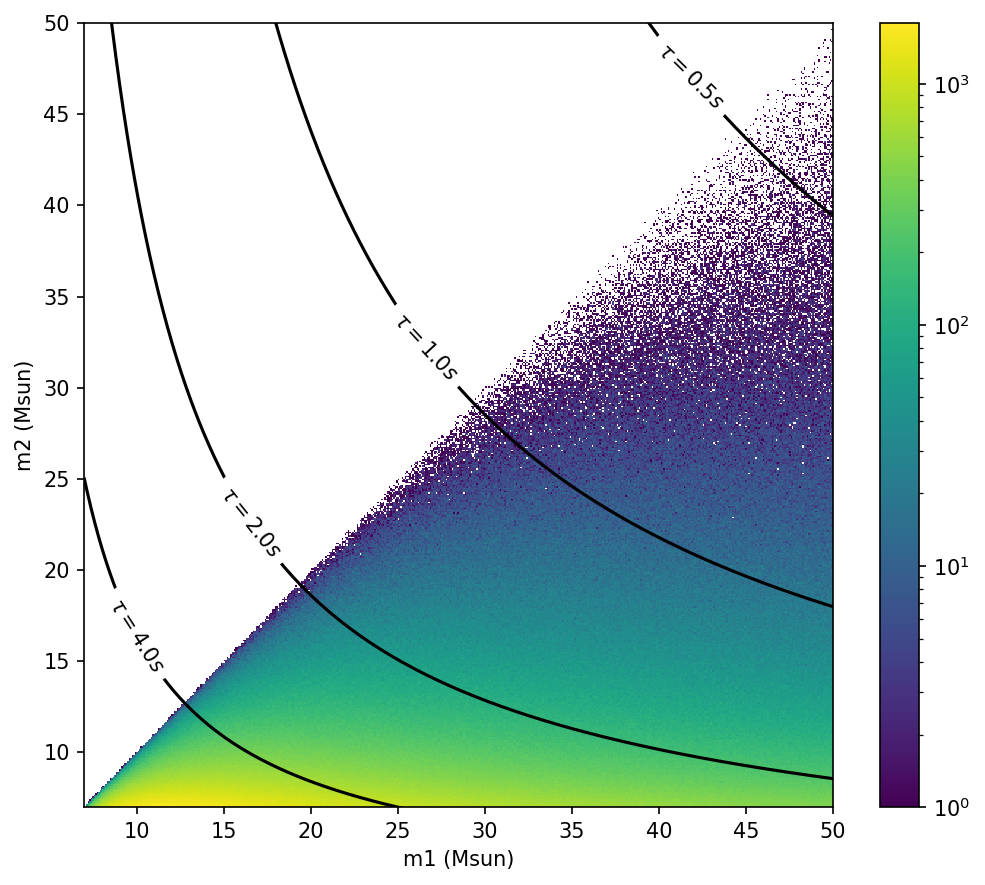

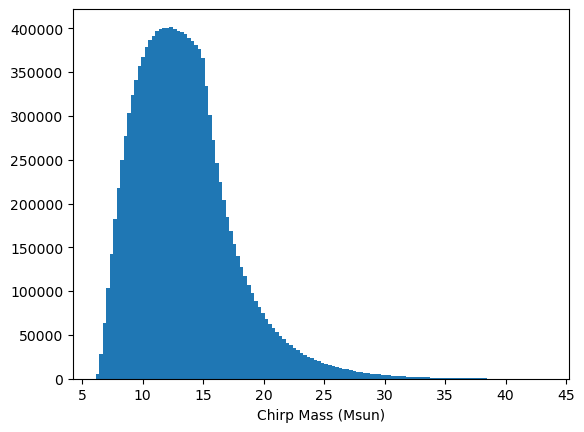

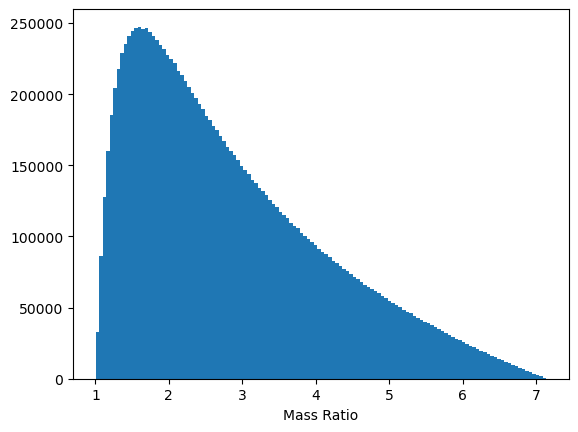

In [16]:
# Convert accepted (tau0, tau3) back to (m1, m2)
amass1 = mass1_from_tau0_tau3(atau0, atau3, f_lower=fL)
amass2 = mass2_from_tau0_tau3(atau0, atau3, f_lower=fL)
amchirp = mchirp_from_mass1_mass2(amass1, amass2)
aq = amass1 / amass2

plt.figure(figsize=(7.0, 6.0), dpi=150)
plt.hist2d(amass1, amass2, bins=512, norm=mpl.colors.LogNorm())

for _tau in [0.5, 1.0, 2.0, 4.0]:
    _mc = mchirp_from_tau(_tau)
    m1_line = np.linspace(m_min, m_max, 1000)
    m2_line = [_mass2_from_mchirp_mass1(mchirp=_mc, mass1=m1i) for m1i in m1_line]
    plt.plot(m1_line, m2_line, c='k', label=r'$\tau={}s$'.format(_tau))

labelLines(plt.gca().get_lines(), xvals=(41.8, 26.6, 16.55, 10), zorder=2.5, fontsize=10)
plt.xlim(m_min, m_max); plt.ylim(m_min, m_max)
plt.xlabel('m1 (Msun)'); plt.ylabel('m2 (Msun)')
plt.colorbar()
plt.tight_layout()
plt.show()

plt.hist(amchirp, bins=128); plt.xlabel('Chirp Mass (Msun)'); plt.show()
plt.hist(aq, bins=128); plt.xlabel('Mass Ratio'); plt.show()

## 4. Uniform (Mchirp, q) Parameterisation

Sample Mchirp uniformly in [Mchirp_min, Mchirp_max] and q uniformly in [1, q_max(Mchirp)], where the upper bound on q depends on the chirp mass via the m1 <= m_max, m2 >= m_min constraints.

In [17]:
def q_upper_boundary_from_mchirp(_mchirp):
    inflection_mchirp = mchirp_from_mass1_mass2(m_max, m_min)
    if _mchirp > inflection_mchirp:
        estimated_m2 = mass2_from_mchirp_mass1(_mchirp, m_max)
        return m_max / estimated_m2
    elif _mchirp < inflection_mchirp:
        estimated_m1 = mass2_from_mchirp_mass1(_mchirp, m_min)
        return estimated_m1 / m_min
    else:
        return m_max / m_min

100%|██████████| 10000000/10000000 [10:10<00:00, 16376.37it/s]


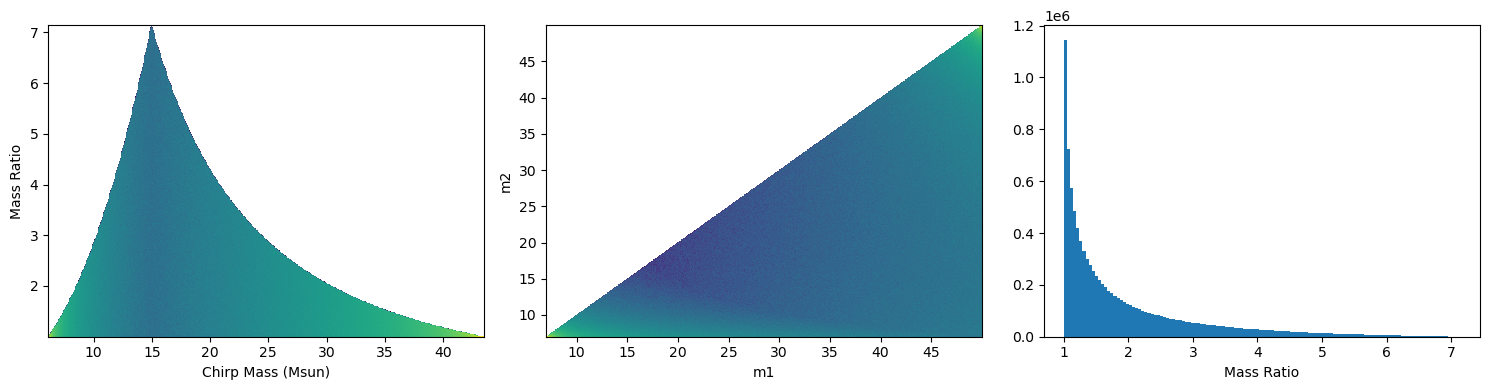

In [18]:
mchirp_low, _ = get_mchirp_priors(m_min, m_min)
_, mchirp_high = get_mchirp_priors(m_max, m_max)
mchirp_low = mchirp_from_mass1_mass2(m_min, m_min)
mchirp_high = mchirp_from_mass1_mass2(m_max, m_max)

umchirp = np.random.uniform(mchirp_low, mchirp_high, num_samples)
uq = []
for _umchirp in tqdm(umchirp):
    ub_q = q_upper_boundary_from_mchirp(_umchirp)
    uq.append(np.random.uniform(1.0, ub_q))
uq = np.array(uq)

mass1_umcq = mass1_from_mchirp_q(umchirp, uq)
mass2_umcq = mass2_from_mchirp_q(umchirp, uq)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist2d(umchirp, uq, bins=512, norm=mpl.colors.LogNorm())
axes[0].set_xlabel('Chirp Mass (Msun)'); axes[0].set_ylabel('Mass Ratio')
axes[1].hist2d(mass1_umcq, mass2_umcq, bins=512, norm=mpl.colors.LogNorm())
axes[1].set_xlabel('m1'); axes[1].set_ylabel('m2')
axes[2].hist(uq, bins=128)
axes[2].set_xlabel('Mass Ratio')
plt.tight_layout()
plt.show()

## 5. Uniform q in (τ₀, q) Space

For each line of constant mass ratio q, τ₀ is bounded from below (m1 = m_max) and above (m2 = m_min). Sampling q uniformly and then τ₀ uniformly within those bounds gives a distribution that is uniform on q.

In [19]:
lines_of_q = np.random.uniform(1.0, m_max / m_min, num_samples)

lower_bound = {}
lower_bound['m1'] = np.full(num_samples, m_max)
lower_bound['m2'] = lower_bound['m1'] / lines_of_q
lower_bound['tau0'] = tau0_from_mass1_mass2(lower_bound['m1'], lower_bound['m2'], f_lower=fL)

upper_bound = {}
upper_bound['m2'] = np.full(num_samples, m_min)
upper_bound['m1'] = upper_bound['m2'] * lines_of_q
upper_bound['tau0'] = tau0_from_mass1_mass2(upper_bound['m1'], upper_bound['m2'], f_lower=fL)

tau_samples = [np.random.uniform(lb, ub) for lb, ub in zip(lower_bound['tau0'], upper_bound['tau0'])]

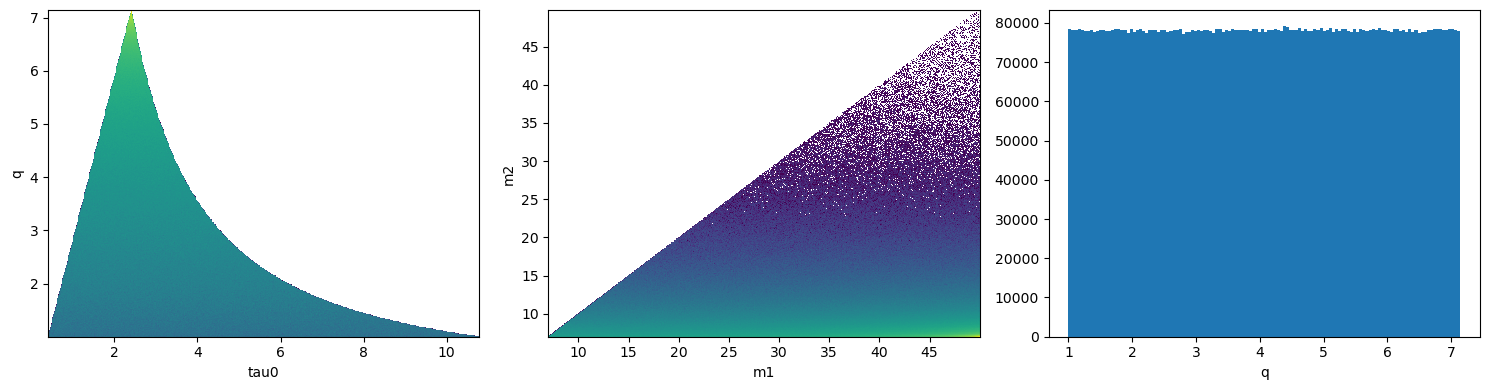

In [20]:
mchirp_from_tau0_arr = mchirp_from_tau0(np.array(tau_samples), f_lower=fL)
m1_from_q = mass1_from_mchirp_q(mchirp_from_tau0_arr, lines_of_q)
m2_from_q = mass2_from_mchirp_q(mchirp_from_tau0_arr, lines_of_q)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist2d(tau_samples, lines_of_q, bins=512, norm=mpl.colors.LogNorm())
axes[0].set_xlabel('tau0'); axes[0].set_ylabel('q')
axes[1].hist2d(m1_from_q, m2_from_q, bins=512, norm=mpl.colors.LogNorm())
axes[1].set_xlabel('m1'); axes[1].set_ylabel('m2')
axes[2].hist(lines_of_q, bins=128)
axes[2].set_xlabel('q')
plt.tight_layout()
plt.show()

## 6. PyCBC Built-in Mass Distributions

PyCBC provides MchirpfromUniformMass1Mass2 and QfromUniformMass1Mass2, which give the correct Jacobian-weighted distributions when the underlying prior is uniform on (m1, m2).

In [21]:
mchirp_low_pycbc = mchirp_from_mass1_mass2(m_min, m_min)
mchirp_high_pycbc = mchirp_from_mass1_mass2(m_max, m_max)

mc_distribution = distributions.MchirpfromUniformMass1Mass2(mc=(mchirp_low_pycbc, mchirp_high_pycbc))
minq = 1.0 / (m_max / m_min)
maxq = m_max / m_min
q_distribution = distributions.QfromUniformMass1Mass2(q=(minq, maxq))

n_pycbc = 100_000
mc_samples = mc_distribution.rvs(size=n_pycbc)
q_samples = q_distribution.rvs(size=n_pycbc)

m1_pycbc = mass1_from_mchirp_q(mc_samples['mc'], q_samples['q'])
m2_pycbc = mass2_from_mchirp_q(mc_samples['mc'], q_samples['q'])

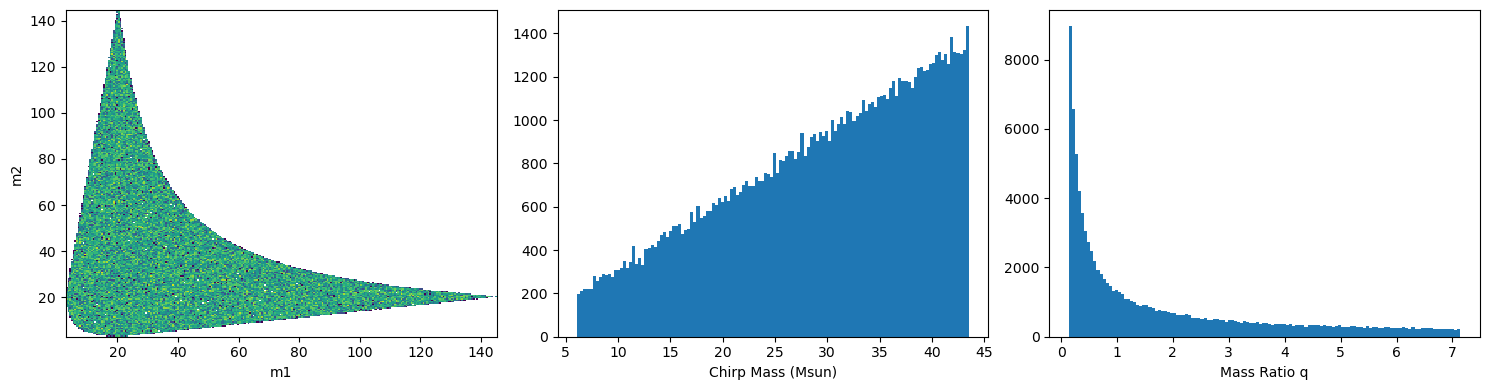

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist2d(m1_pycbc, m2_pycbc, bins=256, norm=mpl.colors.LogNorm())
axes[0].set_xlabel('m1'); axes[0].set_ylabel('m2')
axes[1].hist(mc_samples['mc'], bins=128)
axes[1].set_xlabel('Chirp Mass (Msun)')
axes[2].hist(m1_pycbc / m2_pycbc, bins=128)
axes[2].set_xlabel('Mass Ratio q')
plt.tight_layout()
plt.show()

## 7. Optimal Network SNR over the Prior

Generate waveforms across the mass/spin prior with Sage's IMRPhenomD, project onto H1/L1, and compute the optimal network SNR using the aLIGO Zero Det High Power design PSD. Distances are drawn uniformly in [100, 1000] Mpc to match the training injection setup.

In [23]:
import torch
from sage.core.config import BaseConfig, BaseDataConfig, register_configs
from sage.presets.configs import DefaultConfig as ExampleCFG
from sage.presets.data_configs import Default as ExampleDataCFG
from sage.data.waveform import IMRPhenomD as imr
from sage.data.waveform import project
from pycbc.psd import aLIGOZeroDetHighPower

ImportError: cannot import name 'BaseConfig' from 'sage.core.config' (/home/nagarajan/research/sage/sage/core/config.py)

In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

cfg = BaseConfig(ExampleCFG())
data_cfg = BaseDataConfig(ExampleDataCFG())
register_configs(cfg, data_cfg)

f_l, f_u, del_f = 20.0, 1024.0, 1.0 / 16.0
n_waveform = int(round((f_u - f_l) / del_f)) + 1  # 16065 bins (f_l to f_u)
n_padded   = int(round(f_u / del_f)) + 1           # 16385 bins (0 to f_u)

# Design PSD; bins below f_l carry zero signal so set PSD to inf there
psd_np = np.array(aLIGOZeroDetHighPower(n_padded, del_f, f_l).data[:])
psd_np[:int(f_l / del_f)] = np.inf
psd = torch.tensor(psd_np, dtype=torch.float64, device=device)

In [ ]:
batch_size = 512
n_batches  = 20   # 10 240 total samples
rng = np.random.default_rng(42)

pwave = project.ConstantProjection()

all_snr = []
for _ in tqdm(range(n_batches)):
    m1b  = torch.tensor(rng.uniform(m_min, m_max, batch_size), dtype=torch.float64, device=device)
    m2b  = torch.tensor(rng.uniform(m_min, m_max, batch_size), dtype=torch.float64, device=device)
    m1b, m2b = torch.maximum(m1b, m2b), torch.minimum(m1b, m2b)
    chi1b = torch.tensor(rng.uniform(-0.99, 0.99, batch_size), dtype=torch.float64, device=device)
    chi2b = torch.tensor(rng.uniform(-0.99, 0.99, batch_size), dtype=torch.float64, device=device)
    dist  = torch.tensor(rng.uniform(100.0, 1000.0, batch_size), dtype=torch.float64, device=device)
    tc    = torch.zeros(batch_size, dtype=torch.float64, device=device)
    phic  = torch.tensor(rng.uniform(0.0, 2 * np.pi, batch_size), dtype=torch.float64, device=device)
    incl  = torch.tensor(np.arccos(rng.uniform(-1.0, 1.0, batch_size)), dtype=torch.float64, device=device)
    pol   = torch.tensor(rng.uniform(0.0, np.pi, batch_size), dtype=torch.float64, device=device)
    ra    = torch.tensor(rng.uniform(0.0, 2 * np.pi, batch_size), dtype=torch.float64, device=device)
    dec   = torch.tensor(np.arcsin(rng.uniform(-1.0, 1.0, batch_size)), dtype=torch.float64, device=device)

    params = torch.stack([m1b, m2b, chi1b, chi2b, dist, tc, phic, incl, pol, ra, dec], dim=1)

    f = (f_l + del_f * torch.arange(n_waveform, dtype=torch.float64, device=device)) \
        .unsqueeze(0).expand(batch_size, -1).clone()
    f_ref = torch.full((batch_size, 1), f_l, dtype=torch.float64, device=device)

    hp, hc = imr.IMRPhenomD(f, f_ref)(params, reproduce_lal=True)
    # hp, hc: (B, n_padded) after pad_missing_frequencies

    signal = pwave(hp, hc, ra=ra, dec=dec, polarization=pol)
    # signal: (B, 2, n_padded)

    # rho^2 = (4/df) * sum_det sum_f |h_det(f)|^2 / S_n(f)
    h_sq   = signal.abs().pow(2).sum(dim=1)          # (B, n_padded)
    rho_sq = (4.0 / del_f) * (h_sq / psd).sum(dim=-1)  # (B,)
    all_snr.append(rho_sq.sqrt().cpu().numpy())

all_snr = np.concatenate(all_snr)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(all_snr, bins=64, histtype='stepfilled')
ax.set_xlabel('Optimal Network SNR (aLIGO design, H1+L1)')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f'SNR: median={np.median(all_snr):.1f}, mean={np.mean(all_snr):.1f}, max={np.max(all_snr):.1f}')

## 8. SNR Prior

The injection SNR is drawn from a half-normal distribution shifted to cover the detectable range. This allows the network to see both marginal (SNR ~5) and loud (SNR ~15+) events during training.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
r = halfnorm.rvs(size=1_000_000) * 4.0 + 5.0
ax.hist(r, bins='auto', histtype='stepfilled')
ax.set_xlabel('Optimal Network SNR')
ax.set_ylabel('Number of Occurrences')
plt.show()

In [ ]:
# SNR mean as a linear function of chirp mass
# Lighter binaries are harder to detect, so the mean SNR decreases with Mchirp
lowest_mc_snr_mean = 10.0
highest_mc_snr_mean = 7.0

slope = (highest_mc_snr_mean - lowest_mc_snr_mean) / (mchirp_high_pycbc - mchirp_low_pycbc)
const = lowest_mc_snr_mean - (slope * mchirp_low_pycbc)
mean_snr_given_mc = lambda mc: slope * mc + const

chirp_masses = np.linspace(mchirp_low_pycbc, mchirp_high_pycbc, 1000)
mean_snrs = mean_snr_given_mc(chirp_masses)

plt.figure(figsize=(6, 4))
plt.plot(chirp_masses, mean_snrs)
plt.xlabel('Chirp Mass (Msun)')
plt.ylabel('Mean SNR')
plt.ylim(4.0, 15.0)
plt.grid()
plt.show()